In [22]:
from pathlib import Path
from typing import Optional

import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as stats
from joblib import Parallel, delayed
from tqdm import tqdm

from statsmodels.tsa.arima_process import arma_generate_sample

from lrv_test import LRV, LRVResult
from lrv_test.types import real_function


import seaborn as sns 
sns.set_style("whitegrid")

# ARMA spectral density

In [2]:
def _AR_spectral_density(ar: float) -> real_function:
    return lambda nu: (1 + ar**2 - 2 * ar * np.cos(2 * np.pi * nu)) ** -1

def _MA_spectral_density(ma: float) -> real_function:
    return lambda nu: 1 + ma**2 + 2 * ma * np.cos(2 * np.pi * nu)
                    
def _ARMA_spectral_density(ar: float, ma: float) -> real_function:
    ma_part = _MA_spectral_density(ma)
    ar_part = _AR_spectral_density(ar)
    return lambda nu: ar_part(nu) * ma_part(nu)

def ARMA_spectral_density(ar: np.ndarray | float, ma: np.ndarray | float) -> callable:
    """
    Compute the spectral density of an ARMA(1, 1) process with AR parameter ar and MA parameter ma.
    """
    # check that ar and ma are both arrays of the same shape or both floats
    assert isinstance(ar, np.ndarray) == isinstance(ma, np.ndarray)
    if isinstance(ar, np.ndarray):
        assert ar.shape == ma.shape

    if isinstance(ar, np.ndarray):
        return lambda nu: np.array(
            [_ARMA_spectral_density(ar_i, ma_i)(nu) for ar_i, ma_i in zip(ar, ma)]
        )
    else:
        return _ARMA_spectral_density(ar, ma)

# Limit variance

In [25]:
def run(f: real_function, N: int, M: int, B: int, burn: int, ar: float, ma: float, n_max_freqs: int, oracle_sd: Optional[real_function] = None) -> LRVResult:
    real = arma_generate_sample([1, -ar], [1, ma], (N + burn, M), scale=1 / np.sqrt(2))
    imag = arma_generate_sample([1, -ar], [1, ma], (N + burn, M), scale=1 / np.sqrt(2))
    y = real + 1j * imag
    assert y.shape == (N + burn, M)
    return LRV(y[burn:], B, f, n_max_freqs=n_max_freqs, sd=oracle_sd)

In [31]:
from scipy.stats import norm

ar, ma = 0, 0
oracle_sd = ARMA_spectral_density(ar, ma)

n_max_freqs = 9
f = lambda x: (x-1)**2
n_repeat = 12

N, B, M = 2000, 201, 100
burn = 100

# run in parallel with joblib 
results = Parallel(n_jobs=-1)(delayed(run)(f, N, M, B, burn, ar, ma, n_max_freqs, oracle_sd) for _ in range(n_repeat))

# plot distribution of t_stat_0
fig, ax = plt.subplots()
all_t_stat_0 = np.array([r.t_stat_0 for r in results]).flatten()
ax.hist(all_t_stat_0, bins=30)

# add distribution of a N(0,1)
x_range = np.linspace(np.min(all_t_stat_0), np.max(all_t_stat_0), 100)
ax.plot(x_range, norm.pdf(x_range, 0, 1), label='N(0,1)')
ax.legend()
ax.set_title('Distribution of t_stat_0')


(3.3553189530726717e-15+4.398893998176602j)
ended in 2 iterations
(3.3553189530726717e-15+4.398893998176602j)
ended in 2 iterations
(3.3553189530726717e-15+4.398893998176602j)
ended in 2 iterations
(3.3553189530726717e-15+4.398893998176602j)
ended in 2 iterations


In [21]:
np.std(results[0].t_stat_0)

1.0726367941761439

In [ ]:
from lrv_test.sigma import compute_sigma
compute_sigma(lambda x: 1, c=0.5) #M/B) 

/Users/alexisrosuel/Library/Mobile Documents/com~apple~CloudDocs/Documents/Projets/recherche/lrv-test/src/lrv_test/sigma.py:65: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.real(result))


nan

# CLT
In this section we show that the three CLTs proved in the paper holds

## CLT for each nu

In [ ]:
from lrv_test.theta import p 
from lrv_test.functions import t 

ModuleNotFoundError: No module named 'lrv_test.theta'

In [ ]:
ar, ma = 0.9, 0.9
N, M = 4000, 400  # number of samples, number of time series
burn = 100 # number of values to warmup the arma time series
B = 801
burn=100

# true spectral density of y
oracle_sd = ARMA_spectral_density(ar, ma)

# generate a specific ARMA time series 
real = arma_generate_sample([1, -ar], [1, ma], (N + burn, M), scale=1 / np.sqrt(2))
imag = arma_generate_sample([1, -ar], [1, ma], (N + burn, M), scale=1 / np.sqrt(2))
y = real + 1j * imag

LRV(y[burn:], B, lambda x: (x-1)**2, n_max_freqs=4, sd=oracle_sd)

[1.76170484 0.45531118 0.45368313 1.76173181]
[-0.00016869  0.04635616  0.0464382   0.00054569]


LRVResult(N=4000, M=400, B=801, freqs=array([-0.5    , -0.16675,  0.1665 ,  0.49975]), LSSs=array([2.26045796, 0.9540643 , 0.95243625, 2.26048493]), thetas=array([1.76153615, 0.50166734, 0.50012133, 1.7622775 ]), f_mp=0.49875311731942873, f_Dn=array([-0.00016869,  0.04635616,  0.0464382 ,  0.00054569]))

In [ ]:
from lrv_test.sigma import compute_sigma
compute_sigma(lambda x: x, c: M/B) 

In [ ]:
N, M = 500, 50
burn = 100 
ar, ma = 0, 0
n_max_freqs = 9
B=101
L=7

N, B, M = 1000, 301, 150
f= lambda x: (x-1)**2
f = lambda x: x
# f = lambda x: np.log(x)

# check that n_max_freqs is a perfect square (to make the plots nicely arranged in a grid)
assert np.sqrt(n_max_freqs) == int(np.sqrt(n_max_freqs))


def run(N: int, M: int, burn: int, ar: float, ma: float) -> LRVResult:
    real = arma_generate_sample([1, -ar], [1, ma], (N + burn, M), scale=1 / np.sqrt(2))
    imag = arma_generate_sample([1, -ar], [1, ma], (N + burn, M), scale=1 / np.sqrt(2))
    y = real + 1j * imag
    assert y.shape == (N + burn, M)
n_max_freqs = 9
    return LRV(y[burn:], B, f, n_max_freqs=, L=L, 
            #    f_against_mp=-0.3042995516361173, f_against_D=0.13723660781126862, sigma=5.970657098238504
            # 0.49668874225401205 0.0663521842506548
               )


n_repeat = 8
results = Parallel(n_jobs=-1)(delayed(run)(N, M, burn, ar, ma) for _ in tqdm(range(n_repeat)))

100%|██████████| 8/8 [00:23<00:00,  2.98s/it]

[0.49665038 0.49286009 0.49692542] 0.49668874225401205 0.0663521842506548
[0.49451132 0.49556853 0.49469421] 0.49668874225401205 0.0663521842506548
[0.49535546 0.492807   0.4951503 ] 0.49668874225401205 0.0663521842506548


[0.49191943 0.48856581 0.49177455] 0.49668874225401205 0.0663521842506548
[0.49435246 0.49107286 0.49509877] 0.49668874225401205 0.0663521842506548
[0.49411915 0.48996473 0.49448013] 0.49668874225401205 0.0663521842506548
[0.49446818 0.50368113 0.49511434] 0.49668874225401205 0.0663521842506548
[0.48736561 0.49946702 0.48731697] 0.49668874225401205 0.0663521842506548


In [ ]:
results[1][1]

array([-0.00619476, -0.00593162, -0.00611597])

In [ ]:
results = [r for r, _ in results]

In [ ]:
np.array(results).shape

(8, 3, 150)

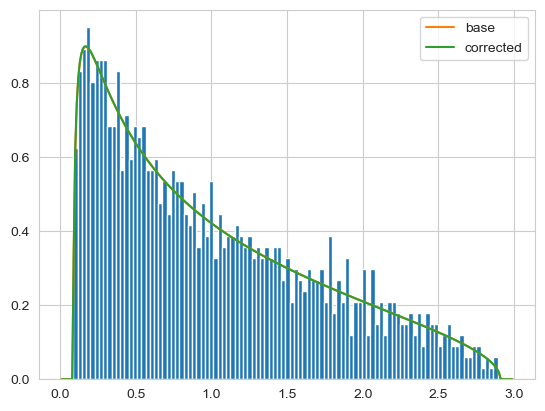

In [ ]:
fig, ax = plt.subplots()

ax.hist(np.array(results)[:,1].flatten(), bins=100, density=True);

c = M/B
y = 1e-8
x_range = np.arange(0.01,3,0.01)
base = 1/np.pi * np.imag([t(x+1j * y, c) for x in x_range])
correction = -0.00651848 * 1/np.pi * np.imag([p(x+1j * y, c) for x in x_range])
ax.plot(x_range, base, label='base')
ax.plot(x_range, base+correction, label='corrected')
ax.legend()

In [ ]:
t = [t for t, sigma in results]

In [ ]:
np.std(np.array(t).flatten())

1.0436613585465875

(array([4., 5., 2., 5., 5., 0., 4., 4., 0., 1.]),
 array([-1.58625335, -1.18148818, -0.77672301, -0.37195784,  0.03280732,
         0.43757249,  0.84233766,  1.24710282,  1.65186799,  2.05663316,
         2.46139832]),
 <BarContainer object of 10 artists>)

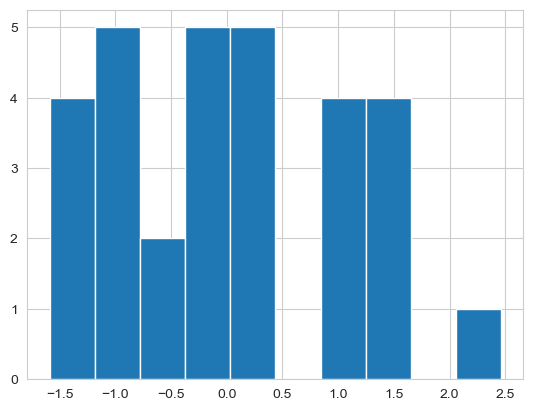

In [ ]:
plt.hist(np.array(t).flatten())

In [ ]:
plt.hist(t)

NameError: name 't' is not defined

In [ ]:
 2 * np.sqrt(2 * (M/B)**2)

1.4095151784449451

In [ ]:
contour.z(0)

NameError: name 'contour' is not defined

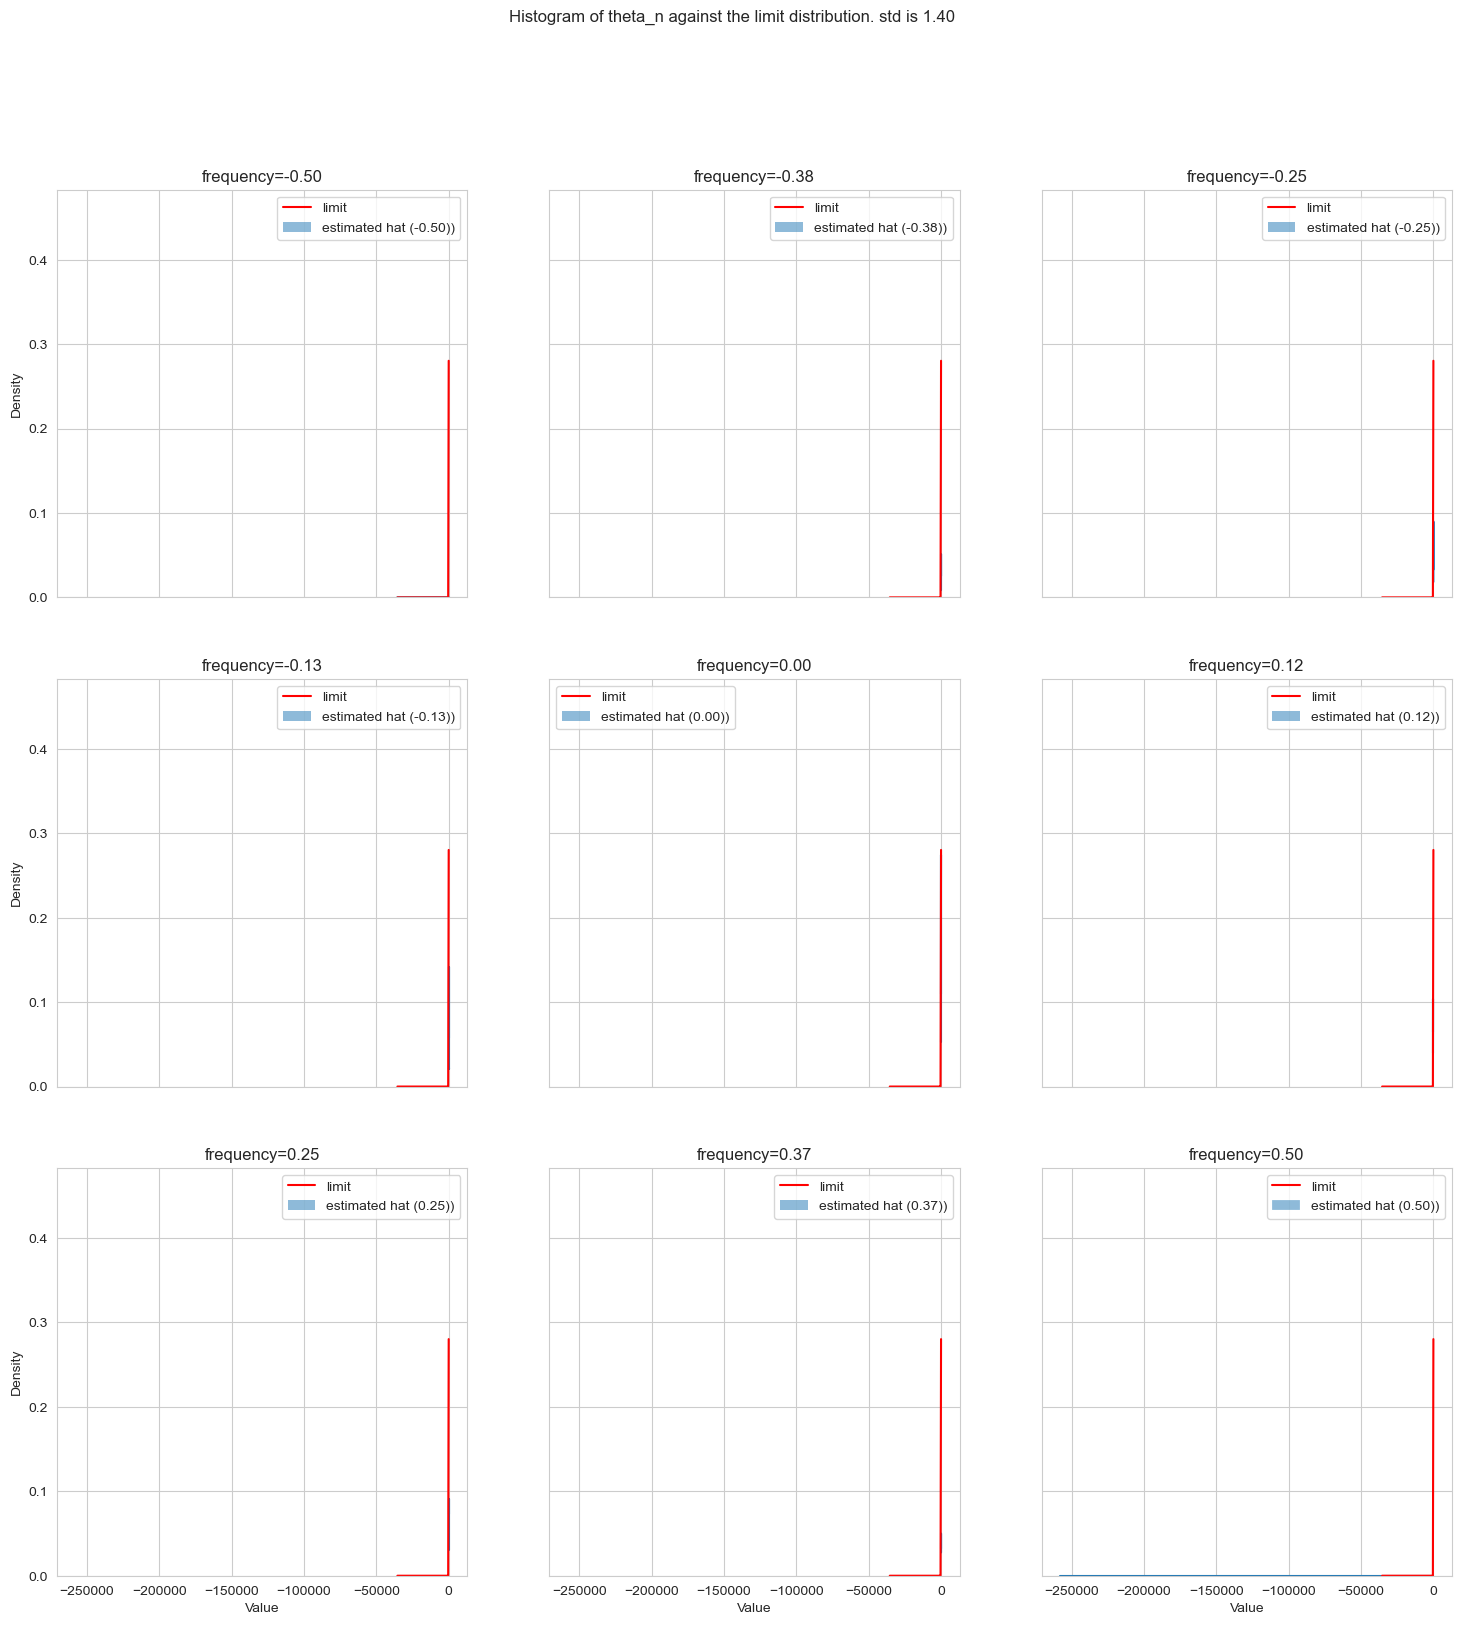

In [ ]:
# extract the first theta_n and theta_n_hat
# for each frequency, plot the histogram of the theta_n vs the limit distribution
n_cols, n_rows = int(np.sqrt(n_max_freqs)), int(np.sqrt(n_max_freqs))

SIZE_FIG = 6
fig, axs = plt.subplots(ncols=n_cols, nrows=n_rows, figsize=(SIZE_FIG*n_cols, SIZE_FIG*n_rows), sharex=True, sharey=True)
axs = axs.flatten()

freqs = results[0].freqs
for i, freq in enumerate(freqs):
    ax = axs[i]

    B_times_theta_ns_freq = np.array([result.B * result.theta_n[i] for result in results]).real
    sns.histplot(B_times_theta_ns_freq, ax=ax, kde=True, label=f'estimated hat ({freq:.2f}))', stat='density')

    # add the distribution of the gaussian equivalent 
    # mu, std = stats.norm.fit(config.B * theta_ns_freq)
    # mu, std = 0, np.std(B_times_theta_ns_freq)
    mu, std = 0, results[0].sigma_N
    x = np.linspace(np.min(B_times_theta_ns_freq), np.max(B_times_theta_ns_freq), num=100)
    ax.plot(x, stats.norm.pdf(x, mu, std), label=f'limit', color='red')

    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.set_title(f'frequency={freq:.2f}')
    ax.legend()

fig.suptitle(f'Histogram of theta_n against the limit distribution. std is {std:.2f}')
plt.show()

# create folder if it does not exist
Path('./plots/clt-single').mkdir(parents=True, exist_ok=True)
fig.savefig('./plots/clt-single/histograms.png')

## CLT for the sum over the frequencies
Here we show that the CLT is valid when summing over frequencies.

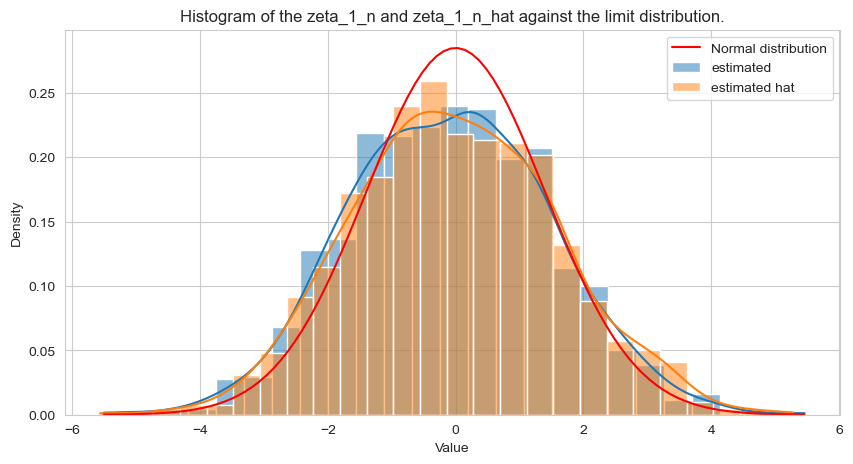

In [ ]:
zeta_1_ns = np.array([result.zeta_1_n for result in results])
zeta_1_n_hats = np.array([result.zeta_1_n_hat for result in results])

mu, std = 0, results[0].sigma_N

# plot histograms of the zeta_1_n and zeta_1_n_hat against the limit distribution
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(zeta_1_ns, ax=ax, kde=True, label=f'estimated', stat='density')
sns.histplot(zeta_1_n_hats.real, ax=ax, kde=True, label=f'estimated hat', stat='density')

# add the distribution of the gaussian equivalent 
x = np.linspace(np.min(zeta_1_ns), np.max(zeta_1_ns), num=100)
ax.plot(x, stats.norm.pdf(x, mu, std), label='Normal distribution', color='red')

ax.legend()
ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.set_title(f'Histogram of the zeta_1_n and zeta_1_n_hat against the limit distribution.')
plt.show()

# create folder if it does not exist
Path('./plots/clt-sum').mkdir(parents=True, exist_ok=True)
fig.savefig('./plots/clt-sum/histograms.png')

## CLT for the square

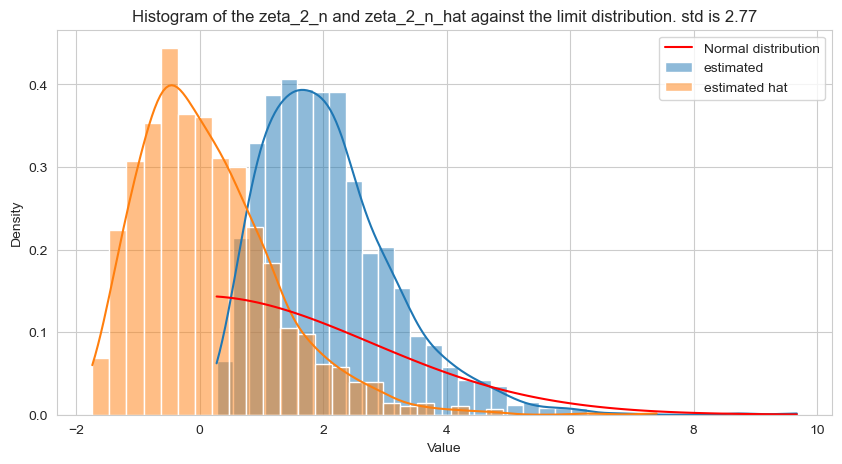

In [ ]:
zeta_2_ns = np.array([result.zeta_2_n for result in results])
zeta_2_n_hats = np.array([result.zeta_2_n_hat for result in results])

mu, std = 0, np.sqrt(2)*results[0].sigma_N**2

# plot histograms of the zeta_2_n
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(zeta_2_ns, ax=ax, kde=True, label=f'estimated', stat='density')
sns.histplot(zeta_2_n_hats.real, ax=ax, kde=True, label=f'estimated hat', stat='density')

# add the distribution of the gaussian equivalent 
x = np.linspace(np.min(zeta_2_ns), np.max(zeta_2_ns), num=100)
ax.plot(x, stats.norm.pdf(x, mu, std), label='Normal distribution', color='red')

ax.legend()
ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.set_title(f'Histogram of the zeta_2_n and zeta_2_n_hat against the limit distribution. std is {std:.2f}')
plt.show()

# create folder if it does not exist
Path('./plots/clt-sum-2').mkdir(parents=True, exist_ok=True)
fig.savefig('./plots/clt-sum-2/histograms.png')